In [3]:
import pandas as pd
import numpy as np
import sklearn
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
wait_times = pd.read_csv('../data/modern_api_wait_times.csv').drop(columns=['id'])

### Filtering out auxillary attractions

In [30]:
keep_rides = [
    "Alice in Wonderland",
    "Casey Jr. Circus Train",
    "Dumbo the Flying Elephant",
    "it's a small world",
    "King Arthur Carrousel",
    "Mad Tea Party",
    "Matterhorn Bobsleds",
    "Mr. Toad's Wild Ride",
    "Peter Pan's Flight",
    "Pinocchio's Daring Journey",
    "Snow White's Enchanted Wish",
    "Storybook Land Canal Boats",
    "Astro Orbitor",
    "Autopia",
    "Buzz Lightyear Astro Blasters",
    "Finding Nemo Submarine Voyage",
    "Space Mountain",
    "Star Tours – The Adventures Continue",
    "Jungle Cruise",
    "Indiana Jones Adventure",
    "The Many Adventures of Winnie the Pooh",
    "Haunted Mansion",
    "Pirates of the Caribbean",
    "Big Thunder Mountain Railroad",
    "Davy Crockett's Explorer Canoes",
    "Mark Twain Riverboat",
    "Sailing Ship Columbia",
    "Chip 'n' Dale's Gadgetcoaster",
    "Roger Rabbit's Car Toon Spin",
    "Mickey & Minnie’s Runaway Railway",
    "Millennium Falcon: Smugglers Run",
    "Star Wars: Rise of the Resistance",
    "Tiana's Bayou Adventure",
    "Disneyland Railroad"
    "Radiator Springs Racers",
    "Incredicoaster",
    "Guardians of the Galaxy – Mission: BREAKOUT!",
    "Toy Story Midway Mania!",
    "Pixar Pal-A-Round",
    "Jessie’s Critter Carousel",
    "Inside Out Emotional Whirlwind",
    "Luigi's Rollickin' Roadsters",
    "Mater's Junkyard Jamboree",
    "The Little Mermaid – Ariel’s Undersea Adventure",
    "Golden Zephyr",
    "Goofy's Sky School",
    "Jumpin' Jellyfish",
    "Silly Symphony Swings",
    "Grizzly River Run",
    "Soarin' Around the World",
    "WEB SLINGERS: A Spider-Man Adventure"
    "Studio Tour",
    "Mario Kart: Bowser’s Challenge",
    "The Secret Life of Pets: Off the Leash",
    "Jurassic World – The Ride",
    "Revenge of the Mummy – The Ride",
    "TRANSFORMERS: The Ride 3D",
    "Harry Potter and the Forbidden Journey",
    "Flight of the Hippogriff",
    "Despicable Me: Minion Mayhem",
    "The Simpsons Ride",
    "Kung Fu Panda Adventure"
    "GhostRider",
    "HangTime",
    "Silver Bullet",
    "Xcelerator",
    "Supreme Scream",
    "Jaguar!",
    "Pony Express",
    "Sierra Sidewinder",
    "Timber Mountain Log Ride",
    "Calico Mine Ride",
    "Calico River Rapids",
    "Sol Spin",
    "Coast Rider",
    "Beagle Express Railroad",
    "Balloon Race"
    "Apocalypse: The Ride",
    "Twisted Colossus",
    "Full Throttle",
    "Wonder Woman: Flight of Courage",
    "BATMAN: The Ride",
    "Canyon Blaster",
    "Gold Rusher",
    "Goliath",
    "Ninja",
    "Jet Stream",
    "The Riddler's Revenge",
    "Scream!",
    "Road Runner Express",
    "Grand American Carousel",
    "Buccaneer",
    "Swashbuckler",
    "Castaway Cove",
    "Magic Flyer",
    "Whistlestop Train",
    "Bonzai Pipelines"
]

In [31]:
wait_times = wait_times[wait_times["Ride_clean"].isin(keep_rides)].copy()

In [40]:
def bucket_time(t):
    hour = int(t.split(':')[0])
    if 8 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    elif 21 <= hour <= 23:
        return 'Night'

def open_hours(row):
    hour = int(row['time'].split(':')[0])
    if row['park'] == "Disneyland":
        if hour < 8:
            return "non-park_hours"
        else:
            return "open"
    elif row['park'] == "Six Flags Magic Mountain":
        if hour < 11 or hour >= 20:
            return "non-park_hours"
        else:
            return "open"
    elif row['park'] == "Disney California Adventure":
        if hour < 8 or hour >= 22:
            return "non-park_hours"
        else:
            return "open"
    elif row['park'] == "Knott' Berry Farm":
        if row['day_of_week'] in ['Saturday', "Friday"]:
            if hour < 10 or hour >= 22:
                return "non-park_hours"
            else:
                return "open"
        elif row['day_of_week'] in ['Sunday']:
            if hour < 10 or hour >= 21:
                return "non-park_hours"
            else:
                return "open"
        elif row['day_of_week'] in ['Thursday']:
            if hour < 10 or hour >= 20:
                return "non-park_hours"
            else:
                return "open"
        else:
            if hour < 11 or hour >= 18:
                return "non-park_hours"
            else:
                return "open"
    elif row['park'] == "Universal Studios Hollywood":
        if hour < 9 or hour >= 20:
            return "non-park_hours"
        else:
            return "open" 
        
wait_times_temporal = wait_times.copy()
wait_times_temporal = wait_times_temporal[['wait_time', 'day_of_week', 'time', 'park']]
#wait_times_temporal['time_bucket'] = wait_times_temporal['time'].apply(bucket_time)
wait_times_temporal['park_open'] = wait_times_temporal.apply(open_hours, axis=1)
wait_times_temporal = wait_times_temporal[wait_times_temporal['park_open'] != 'non-park_hours']
wait_times_temporal['hour'] = wait_times_temporal['time'].apply(lambda x: int(x.split(':')[0]))

wait_times_temporal = wait_times_temporal.drop(columns=['time', 'park_open', "park"])
#wait_times_temporal['time_bucket'] = pd.Categorical(wait_times_temporal['time_bucket'], categories= ["Morning", "Afternoon", "Evening", "Night"], ordered=True)

wait_times_temporal.head(5)

,wait_time,day_of_week,hour
2275,0,Monday,9
2607,0,Monday,8
2609,0,Monday,8
2610,0,Monday,8
2611,0,Monday,8


In [47]:
wait_times_temporal_encoded = pd.get_dummies(wait_times_temporal, columns=["hour"], drop_first=True)
wait_times_temporal_encoded.drop(columns=['day_of_week'], inplace=True)
wait_times_temporal_encoded = wait_times_temporal_encoded.astype(int)

wait_times_temporal_encoded.head(5)

,wait_time,hour_9,hour_10,hour_11,hour_12,hour_13,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
2275,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2607,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2609,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2610,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2611,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [48]:
X = wait_times_temporal_encoded.drop(columns=['wait_time'])
y = wait_times_temporal_encoded['wait_time']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              wait_time   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.378
Method:                 Least Squares   F-statistic:                     2715.
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:18:09   Log-Likelihood:            -2.6919e+05
No. Observations:               67001   AIC:                         5.384e+05
Df Residuals:                   66985   BIC:                         5.386e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1752      0.246      0.713      0.4

In [56]:
model.params[0]

C:\Users\mikec\AppData\Local\Temp\ipykernel_39448\629825848.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  model.params[0]


0.17523364485958082

C:\Users\mikec\AppData\Local\Temp\ipykernel_39448\3668213455.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefs = model.params.drop("const") + model.params[0]


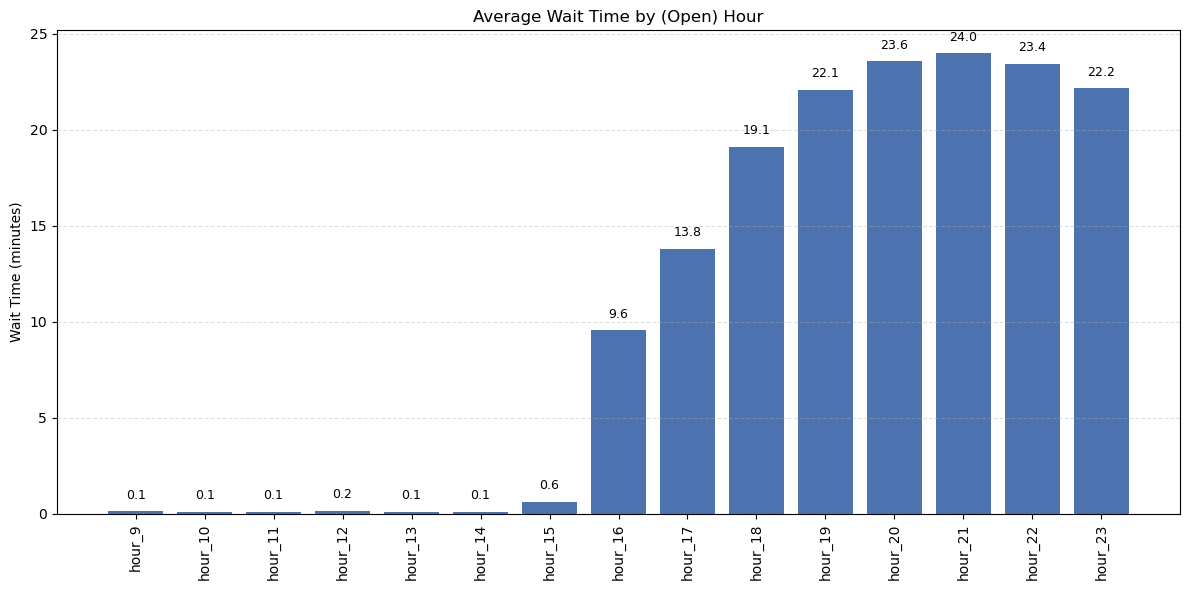

In [61]:
coefs = model.params.drop("const") + model.params[0]
features = coefs.index
values = coefs.values

plt.figure(figsize=(12,6))

bars = plt.bar(features, values, color="#4C72B0")

plt.xticks(rotation=90)
plt.ylabel("Wait Time (minutes)")
plt.title("Average Wait Time by (Open) Hour")

plt.grid(axis="y", linestyle="--", alpha=0.4)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


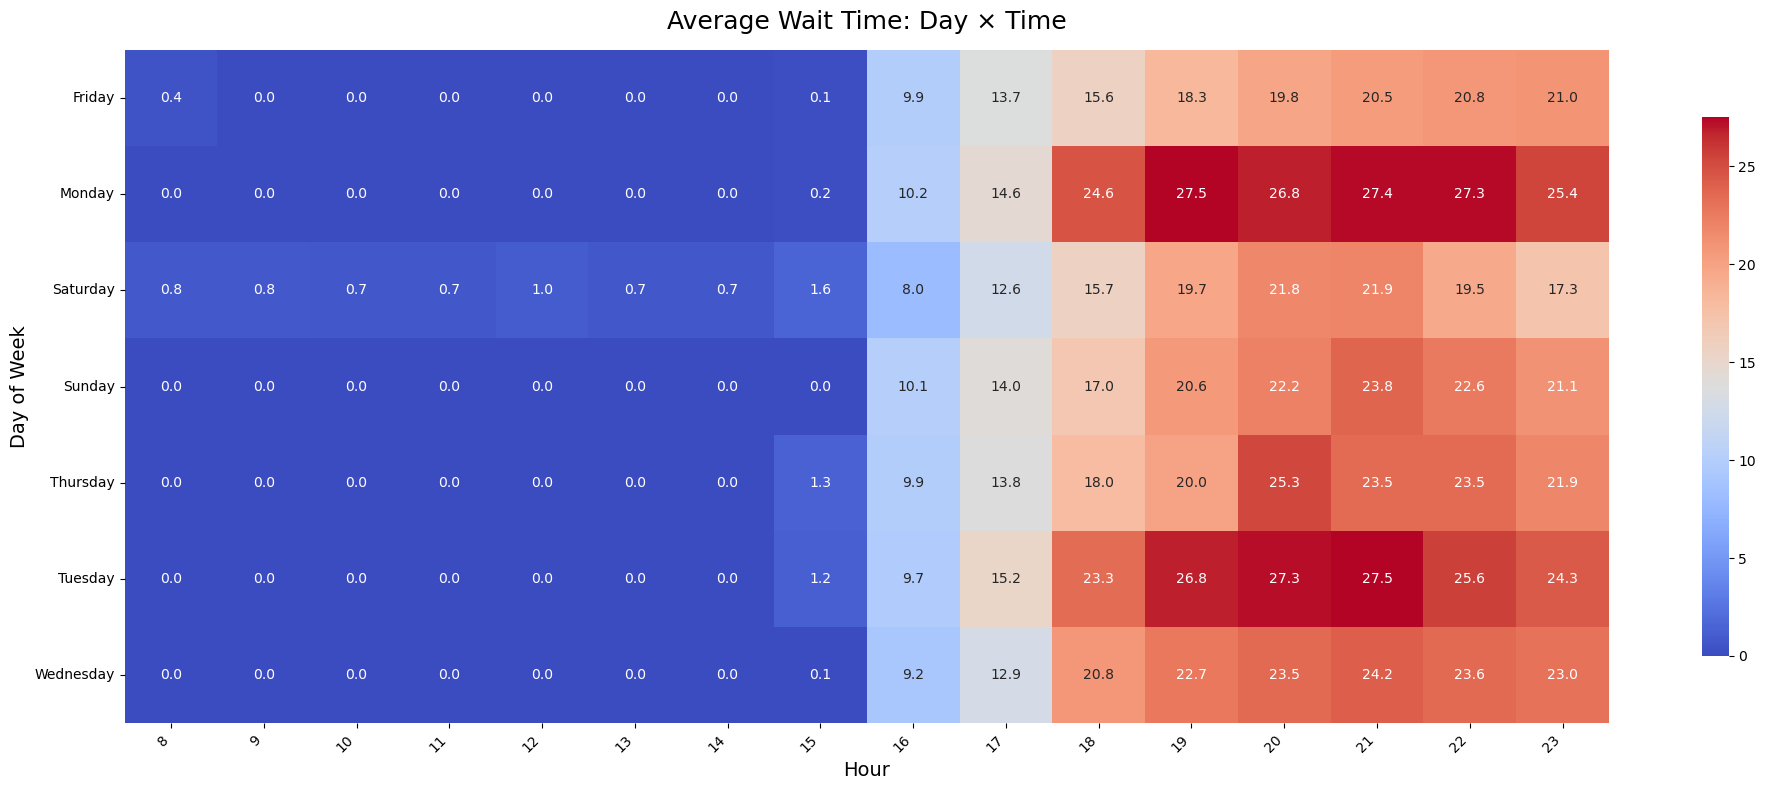

In [64]:
plt.figure(figsize=(20, 8))  # wider + taller

sns.heatmap(
    pivot,
    cmap='coolwarm',
    annot=True,
    fmt=".1f",
    annot_kws={"size": 10},   # number font size
    cbar_kws={"shrink": 0.8}  # smaller colorbar
)

plt.title("Average Wait Time: Day × Time", fontsize=18, pad=15)
plt.ylabel("Day of Week", fontsize=14)
plt.xlabel("Hour", fontsize=14)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()
